In [1]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [2]:
try:
    import pandas
except ImportError:
    %pip install pandas

try:
    import numpy
except ImportError:
    %pip install numpy

try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

try:
    import matplotlib
except ImportError:
    %pip install matplotlib

In [3]:
import statadict

In [4]:
dct_file = "data/2002FemPreg.dct"
dat_file = "data/2002FemPreg.dat.gz"

In [5]:
from statadict import parse_stata_dict

stata_dict = parse_stata_dict(dct_file)
#stata_dict.colspecs

[(0, 12),
 (12, 14),
 (14, 16),
 (16, 17),
 (17, 18),
 (18, 19),
 (19, 20),
 (20, 21),
 (21, 22),
 (22, 23),
 (23, 27),
 (27, 28),
 (28, 32),
 (32, 33),
 (33, 37),
 (37, 39),
 (39, 41),
 (41, 43),
 (43, 45),
 (45, 47),
 (47, 49),
 (49, 50),
 (50, 51),
 (51, 52),
 (52, 53),
 (53, 54),
 (54, 55),
 (55, 56),
 (56, 58),
 (58, 60),
 (60, 61),
 (61, 62),
 (62, 64),
 (64, 66),
 (66, 67),
 (67, 68),
 (68, 70),
 (70, 72),
 (72, 73),
 (73, 77),
 (77, 81),
 (81, 83),
 (83, 84),
 (84, 85),
 (85, 86),
 (86, 87),
 (87, 89),
 (89, 90),
 (90, 91),
 (91, 92),
 (92, 93),
 (93, 94),
 (94, 95),
 (95, 97),
 (97, 98),
 (98, 99),
 (99, 100),
 (100, 101),
 (101, 102),
 (102, 104),
 (104, 105),
 (105, 107),
 (107, 108),
 (108, 109),
 (109, 110),
 (110, 114),
 (114, 118),
 (118, 121),
 (121, 122),
 (122, 123),
 (123, 124),
 (124, 125),
 (125, 126),
 (126, 129),
 (129, 130),
 (130, 133),
 (133, 134),
 (134, 137),
 (137, 138),
 (138, 141),
 (141, 142),
 (142, 143),
 (143, 144),
 (144, 148),
 (148, 152),
 (152, 15

In [6]:
from statadict import parse_stata_dict
import pandas as pd

def read_stats(dct_file, dat_file):
    stata_dict = parse_stata_dict(dct_file)
    resp = pd.read_fwf(dat_file, names = stata_dict.names, colspecs= stata_dict.colspecs, compression = "gzip")
    return resp

In [7]:
dct_file = "data/2002FemPreg.dct"
dat_file = "data/2002FemPreg.dat.gz"
preg = read_stats(dct_file, dat_file)

In [8]:
preg.shape
preg.head()
preg.columns

Index(['caseid', 'pregordr', 'howpreg_n', 'howpreg_p', 'moscurrp', 'nowprgdk',
       'pregend1', 'pregend2', 'nbrnaliv', 'multbrth',
       ...
       'poverty_i', 'laborfor_i', 'religion_i', 'metro_i', 'basewgt',
       'adj_mod_basewgt', 'finalwgt', 'secu_p', 'sest', 'cmintvw'],
      dtype='object', length=243)

In [9]:
preg["outcome"].value_counts().sort_index()

outcome
1    9148
2    1862
3     120
4    1921
5     190
6     352
Name: count, dtype: int64

In [10]:
counts = preg["birthwgt_lb"].value_counts(dropna=False).sort_index()
counts

birthwgt_lb
0.0        8
1.0       40
2.0       53
3.0       98
4.0      229
5.0      697
6.0     2223
7.0     3049
8.0     1889
9.0      623
10.0     132
11.0      26
12.0      10
13.0       3
14.0       3
15.0       1
51.0       1
97.0       1
98.0       1
99.0      57
NaN     4449
Name: count, dtype: int64

In [11]:
counts.loc[0:5]

birthwgt_lb
0.0      8
1.0     40
2.0     53
3.0     98
4.0    229
5.0    697
Name: count, dtype: int64

In [12]:
counts.loc[0:5].sum()

np.int64(1125)

In [13]:
import numpy as np
#preg["birthwgt_lb"] = preg["birthwgt_lb"].replace([51,97,98,99],np.nan)
preg.loc[preg.birthwgt_lb > 20 ,"birthwgt_lb"] = np.nan

In [56]:
preg["agepreg"] /= 100.0
preg["agepreg"].mean()

np.float64(24.6881511970395)

In [15]:
preg["birthwgt_oz"].value_counts(dropna=False).sort_index()

birthwgt_oz
0.0     1037
1.0      408
2.0      603
3.0      533
4.0      525
5.0      535
6.0      709
7.0      501
8.0      756
9.0      505
10.0     475
11.0     557
12.0     555
13.0     487
14.0     475
15.0     378
97.0       1
98.0       1
99.0      46
NaN     4506
Name: count, dtype: int64

In [16]:
preg["birthwgt_oz"] = preg["birthwgt_oz"].replace([97,98,99],np.nan)

In [17]:
preg["totalwgt_lb"] = preg["birthwgt_lb"] + preg["birthwgt_oz"] /16.0
preg["totalwgt_lb"].mean()

np.float64(7.265628457623368)

In [18]:
weights = preg["totalwgt_lb"]
weights_mean = weights.mean()
n = weights.count() #counts the row with no nan
squared_deviation = (weights - weights_mean) ** 2
squared_deviation
variance = squared_deviation.sum()/n  # or you can use weights.var(ddof = 0)
variance

np.float64(1.983070989750022)

In [19]:
weights.var()

np.float64(1.9832904288326545)

In [20]:
weights.var(ddof = 0)

np.float64(1.983070989750022)

In [21]:
std = np.sqrt(variance)
std

np.float64(1.40821553384062)

In [22]:
weights.std(ddof = 0)

np.float64(1.40821553384062)

In [23]:
subset = preg.query("caseid == 10229")
subset

,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,laborfor_i,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw,totalwgt_lb
11093,10229,1,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,0,0,0,1914.323805,2021.999794,3369.662656,2,65,1232,NaN
11094,10229,2,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,0,0,0,1914.323805,2021.999794,3369.662656,2,65,1232,NaN
11095,10229,3,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,0,0,0,1914.323805,2021.999794,3369.662656,2,65,1232,NaN
11096,10229,4,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,0,0,0,1914.323805,2021.999794,3369.662656,2,65,1232,NaN
11097,10229,5,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,0,0,0,1914.323805,2021.999794,3369.662656,2,65,1232,NaN
11098,10229,6,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,0,0,0,1914.323805,2021.999794,3369.662656,2,65,1232,NaN
11099,10229,7,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,1914.323805,2021.999794,3369.662656,2,65,1232,7.6875


In [24]:
subset["outcome"].values

array([4, 4, 4, 4, 4, 4, 1])

In [25]:
preg["birthord"].value_counts(dropna = False).sort_index()

birthord
1.0     4413
2.0     2874
3.0     1234
4.0      421
5.0      126
6.0       50
7.0       20
8.0        7
9.0        2
10.0       1
NaN     4445
Name: count, dtype: int64

In [26]:
preg["totalwgt_kg"]= preg["totalwgt_lb"]/2.2
mean_kg = preg["totalwgt_kg"].mean()
mean_kg

np.float64(3.3025583898288033)

In [27]:
std_kg = preg["totalwgt_kg"].std(ddof = 0)
std_kg

np.float64(0.6400979699275544)

In [28]:
subset = preg.query("caseid == 2298 or caseid == 5013")

In [29]:
subset

,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw,totalwgt_lb,totalwgt_kg
2610,2298,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,3247.916977,5123.759559,5556.717241,2,18,1234,6.8750,3.125000
2611,2298,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,3247.916977,5123.759559,5556.717241,2,18,1234,5.5000,2.500000
2612,2298,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,3247.916977,5123.759559,5556.717241,2,18,1234,4.1875,1.903409
2613,2298,4,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,3247.916977,5123.759559,5556.717241,2,18,1234,6.8750,3.125000
5516,5013,1,NaN,NaN,NaN,NaN,5.0,NaN,1.0,NaN,...,0,0,3643.044395,4548.148695,6132.268885,1,25,1231,7.3750,3.352273
5517,5013,2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,3643.044395,4548.148695,6132.268885,1,25,1231,NaN,NaN
5518,5013,3,NaN,NaN,NaN,NaN,5.0,NaN,1.0,NaN,...,0,0,3643.044395,4548.148695,6132.268885,1,25,1231,8.3125,3.778409
5519,5013,4,NaN,NaN,NaN,NaN,5.0,NaN,1.0,NaN,...,0,0,3643.044395,4548.148695,6132.268885,1,25,1231,8.1250,3.693182


Chapter 2

In [30]:
from empiricaldist import FreqTab
import matplotlib.pyplot as plt

t = [1.0, 2.0, 2.0, 3.0, 5.0]
ftab = FreqTab.from_seq(t)
ftab

,freqs
1.0,1
2.0,2
3.0,1
5.0,1


Text(0, 0.5, 'Frequency')

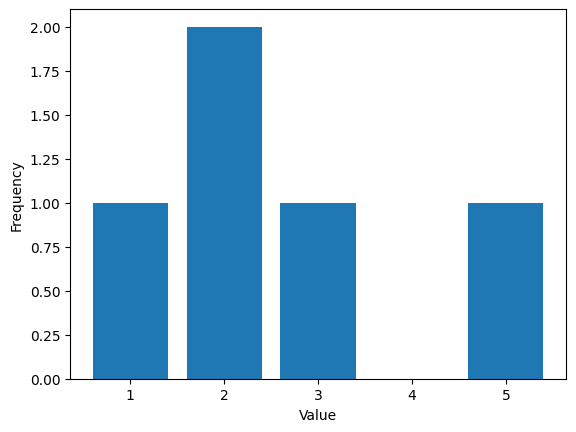

In [31]:
ftab.bar()
plt.xlabel("Value")
plt.ylabel("Frequency")

In [32]:
ftab.qs

array([1., 2., 3., 5.])

In [33]:
ftab.fs

array([1, 2, 1, 1])

In [34]:
for x, freq in ftab.items():
    print(x, freq)

1.0 1
2.0 2
3.0 1
5.0 1


In [35]:
preg["hpagelb"] = preg.hpagelb.replace([97,98,99], np.nan)
preg["babysex"] = preg.babysex.replace([7, 9], np.nan)
preg["nbrnaliv"] = preg.nbrnaliv.replace([9], np.nan)

In [57]:
live = preg.query("outcome == 1")
#live = preg.loc[preg.outcome == 1]
#live

In [46]:
ftab_lb = FreqTab.from_seq(live["birthwgt_lb"], name = "birthwgt_lb")

Text(0, 0.5, 'Frequency')

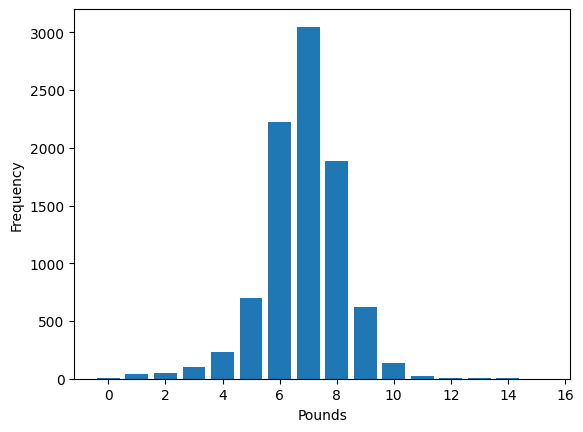

In [49]:
ftab_lb.bar()
plt.xlabel("Pounds")
plt.ylabel("Frequency")

In [50]:
#mode: most common value
ftab_lb.mode() #or ftab_lb.idxmax()

np.float64(7.0)

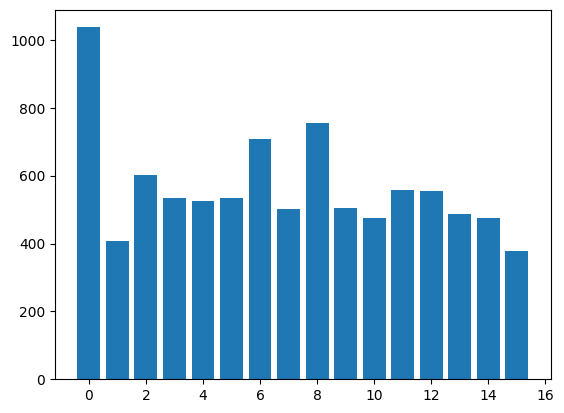

In [51]:
ftab_oz = FreqTab.from_seq(live["birthwgt_oz"], name = "birthwgt_oz")
ftab_oz.bar()

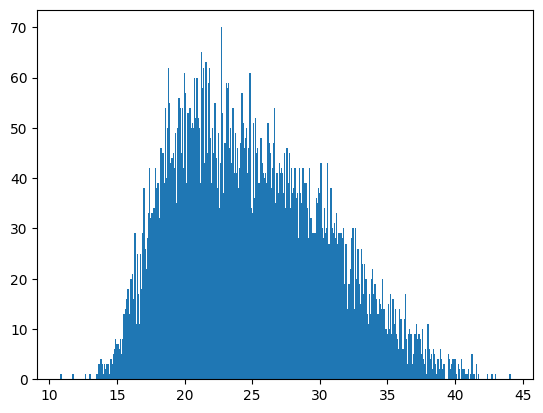

In [61]:

ftab_age = FreqTab.from_seq(live["agepreg"], name = "agepreg")
ftab_age.bar(width = 0.1)
#ftab_age

(20.0, 50.0)

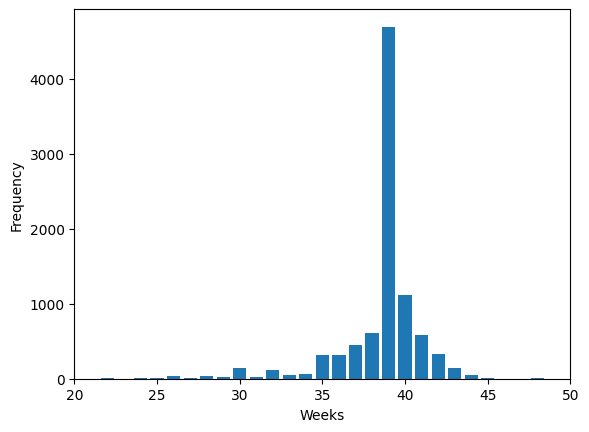

In [63]:
ftab_prglngth = FreqTab.from_seq(live["prglngth"], name = "prglngth")
ftab_prglngth.bar()
plt.xlabel("Weeks")
plt.ylabel("Frequency")
plt.xlim(20,50)

In [64]:
def smallest (ftab, n=10):
    return ftab[:n]

smallest(ftab_prglngth)

prglngth
0     1
4     1
9     1
13    1
17    2
18    1
19    1
20    1
21    2
22    7
Name: prglngth, dtype: int64

In [66]:
def largest (ftab, n=10):
    return ftab[-n:]

largest(ftab_prglngth)

prglngth
40    1116
41     587
42     328
43     148
44      46
45      10
46       1
47       1
48       7
50       2
Name: prglngth, dtype: int64

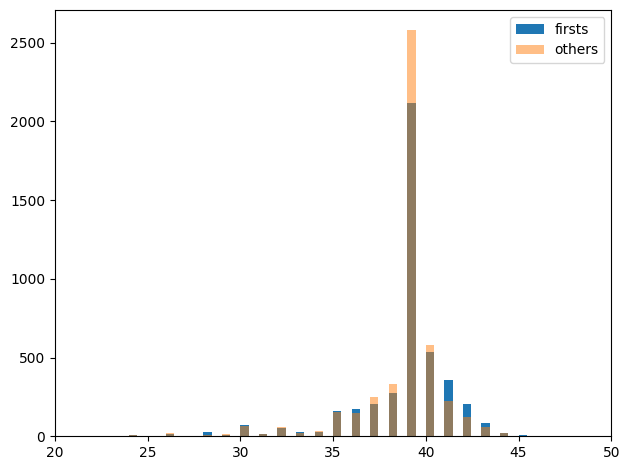

In [74]:
firsts = live.query("birthord == 1")
others = live.query("birthord != 1")

ftab_firsts = FreqTab.from_seq(firsts["prglngth"], name = "firsts")
ftab_others = FreqTab.from_seq(others["prglngth"], name = "others")

def two_bar_plots(ftab1, ftab2, width = 0.45):
    ftab1.bar(align = "edge", width = width)
    ftab2.bar(align = "edge", width = width, alpha = 0.5)

two_bar_plots(ftab_firsts, ftab_others)
plt.xlim(20,50)
plt.tight_layout()
plt.legend()

In [75]:
firsts["prglngth"].count()

np.int64(4413)

In [76]:
others["prglngth"].count()

np.int64(4735)

In [77]:
firsts["prglngth"].mean()

np.float64(38.60095173351461)

In [78]:
others["prglngth"].mean()

np.float64(38.52291446673706)